<a href="https://colab.research.google.com/github/thvsbg/PyTorch/blob/main/01_Pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [2]:
weight=0.7
bias=0.3

start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(1)
y=weight*X+bias
print(y[:10])
# print(X)

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


In [3]:
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [119]:
def plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  plt.figure(figsize=(4,4))
  plt.scatter(train_data,train_labels,c="b")
  plt.scatter(test_data,test_labels,c="g")
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r")
  plt.xticks(torch.arange(0,1,0.1))
  plt.yticks(torch.arange(0,1,0.1))
  plt.show()

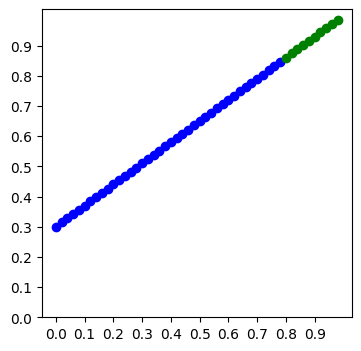

In [5]:
plot_predictions()

In [6]:
##create linear regression model
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights=nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
    self.bias=nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))

  def forward(self,x:torch.Tensor):
    return self.weights*x+self.bias


In [7]:
torch.manual_seed(42)
torch.randn(1)


tensor([0.3367])

In [8]:
torch.manual_seed(42)
model_0=LinearRegression()
list(model_0.parameters())


[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [9]:
##to get named paramters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [10]:
y_pred=model_0(X_test)
y_pred

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

Making predictions using torch.inference_mode()

In [11]:
with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds


tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [14]:
loss_fn=nn.L1Loss()
opt=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

Training loop

In [116]:
epochs= 1

# 0 Loop through the data
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() # train mode sets all the paramters with "require grad=True" to require gradient

  #1. Forward pass
  y_pred=model_0(X_train)

  #2. calculate loss
  loss=loss_fn(y_pred,y_train)
  print(f'loss is : {loss}')
  #3. Optimizer zero grad
  opt.zero_grad()

  #4. perform backpropagation on the loss wrt to paramters of the model
  loss.backward()

  #5. step the optimizer
  opt.step()

  model_0.eval()

  print(model_0.state_dict())






loss is : 0.007095950655639172
OrderedDict({'weights': tensor([0.6938]), 'bias': tensor([0.2980])})


In [120]:
with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds

tensor([[0.8530],
        [0.8669],
        [0.8808],
        [0.8946],
        [0.9085],
        [0.9224],
        [0.9363],
        [0.9501],
        [0.9640],
        [0.9779]])

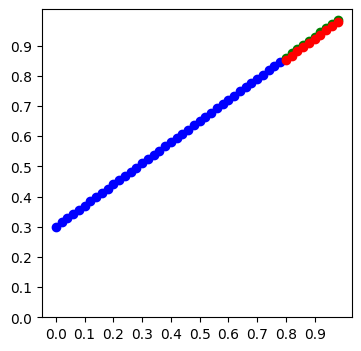

In [121]:
plot_predictions(predictions=y_preds)